In [98]:
from tensorflow.keras.datasets import mnist



In [95]:

(X_train, Y_train),(X_test, Y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 68s 6us/step


In [100]:
# flatten 
X_train=X_train.reshape(-1,28*28)
X_test=X_test.reshape(-1,28*28)


In [101]:
# Scale pixel values to match sklearn digits style (0–16)
X_train=(X_train/255.0)*16
X_test=(X_test/255.0)*16


In [102]:
# Define hyperparameter grid
from sklearn.neighbors import KNeighborsClassifier
param={
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator=KNeighborsClassifier(), param_grid=param, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)


In [103]:
# Fit GridSearchCV
grid.fit(X_train,Y_train)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=2)

In [104]:

print(f"✅ Best Parameters: {grid.best_params_}")
print(f"📊 Best CV Score: {grid.best_score_:.4f}")


✅ Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
📊 Best CV Score: 0.9693


In [106]:

# Train best model on full training set
best_knn = grid.best_estimator_
final_accuracy = best_knn.score(X_test, Y_test)
print(f"🎯 Final Test Accuracy: {final_accuracy:.4f}")


🎯 Final Test Accuracy: 0.9717


In [107]:
# save the modle
import joblib
joblib.dump(best_knn, "knn_mnist_model.pkl")
print("💾 Model saved as knn_mnist_model.pkl")


💾 Model saved as knn_mnist_model.pkl


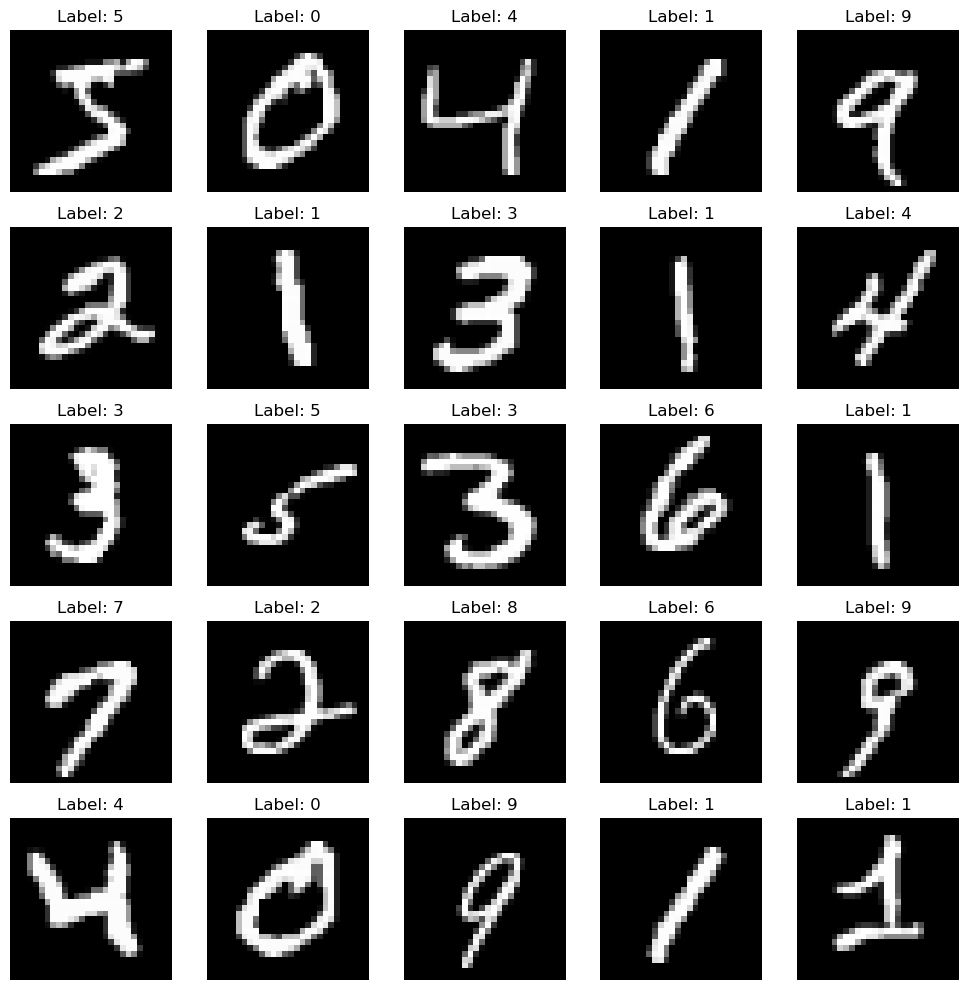

In [108]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Function to plot a grid of images
def plot_mnist_samples(images, labels, n_rows=5, n_cols=5):
    plt.figure(figsize=(n_cols*2, n_rows*2))
    for i in range(n_rows * n_cols):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot first 25 images from training set
plot_mnist_samples(X_train, y_train, n_rows=5, n_cols=5)
